In [2]:
import pandas as pd
import numpy as np

In [3]:
df=pd.read_csv('/content/Sample - Sheet1.csv')

In [4]:
df.head()

,StudyHours,Attendence,PastScore,Internet,SleepHours,Passed
0,2,60,40,Yes,5,No
1,5,80,60,No,6,Yes
2,8,90,75,Yes,8,Yes
3,3,70,50,Yes,5,No
4,7,85,70,No,7,Yes


In [5]:
print(f'Row:{df.shape[0]},column:{df.shape[1]}')

Row:20,column:6


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   StudyHours  20 non-null     int64 
 1   Attendence  20 non-null     int64 
 2   PastScore   20 non-null     int64 
 3   Internet    20 non-null     object
 4   SleepHours  20 non-null     int64 
 5   Passed      20 non-null     object
dtypes: int64(4), object(2)
memory usage: 1.1+ KB


In [7]:
df.describe()

,StudyHours,Attendence,PastScore,SleepHours
count,20.000000,20.000000,20.00000,20.000000
mean,5.100000,73.650000,59.10000,6.050000
std,2.845125,16.971416,19.41215,2.038446
min,1.000000,40.000000,25.00000,3.000000
25%,2.750000,60.000000,43.75000,4.750000
50%,5.000000,77.000000,62.50000,6.000000
75%,7.250000,85.750000,72.75000,7.250000
max,10.000000,99.000000,90.00000,10.000000


In [8]:
df.isnull().sum()

,0
StudyHours,0
Attendence,0
PastScore,0
Internet,0
SleepHours,0
Passed,0


In [10]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Internet']=le.fit_transform(df['Internet']) # yes=1,no=0
df['Passed']=le.fit_transform(df['Passed'])     # yes=1,no=0
df.head()

,StudyHours,Attendence,PastScore,Internet,SleepHours,Passed
0,2,60,40,1,5,0
1,5,80,60,0,6,1
2,8,90,75,1,8,1
3,3,70,50,1,5,0
4,7,85,70,0,7,1


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix,classification_report

Classification Report:-
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         3

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



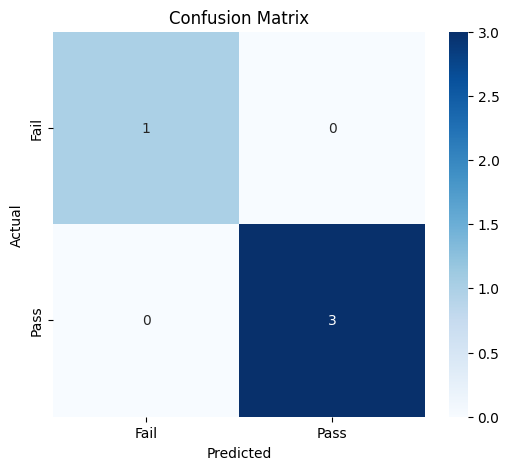

---------Predict Your Result---------
Enter Study Hours:10
Enter Attendence:75
Enter Past Score:65
Enter Sleep Hours:4
Prediction: Pass


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [13]:
features = ['StudyHours','Attendence','PastScore','SleepHours']
scaler=StandardScaler()
df_scaled=df.copy()
df_scaled[features]= scaler.fit_transform(df[features])
x=df_scaled[features]
y=df_scaled['Passed']
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2, random_state=42)
model=LogisticRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print("Classification Report:-")
print(classification_report(y_test,y_pred))
conf_matrix=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix,annot=True,fmt='d',cmap='Blues',
            xticklabels=['Fail','Pass'],yticklabels=['Fail','Pass'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("---------Predict Your Result---------")
try:
  study_hours=float(input("Enter Study Hours:"))
  attendence=float(input("Enter Attendence:"))
  past_score=float(input("Enter Past Score:"))
  sleep_hours=float(input("Enter Sleep Hours:"))
  user_input_df=pd.DataFrame({
      'StudyHours':[study_hours],
      'Attendence':[attendence],
      "PastScore":[past_score],
      'SleepHours':[sleep_hours]
  })
  user_input_scaled = scaler.transform(user_input_df)
  prediction = model.predict(user_input_scaled)[0]
  result = "Pass" if prediction == 1 else "Fail"
  print(f"Prediction: {result}")
except ValueError:
  print("Invalid input. Please enter valid numerical values.")